# LangGraph 단기 메모리 관리

단기 메모리(Short-term Memory)는 하나의 대화 세션(thread) 내에서 이전 상호작용을 기억하는 메커니즘입니다. LangGraph에서는 체크포인터를 통해 대화 기록을 저장하고, 동일한 `thread_id`로 호출하면 이전 대화를 이어서 진행할 수 있습니다.

그러나 대화가 길어지면 LLM의 컨텍스트 윈도우 제한에 도달하거나 토큰 비용이 증가하는 문제가 발생합니다. 이를 해결하기 위해 메시지 트리밍(trimming), 삭제(deletion), 요약(summarization) 등의 전략을 사용합니다.

> 참고 문서: [LangGraph Persistence](https://langchain-ai.github.io/langgraph/concepts/persistence/)

## 학습 목표

이 튜토리얼에서는 다음 내용을 학습합니다:

- 메시지 트리밍(trim_messages)을 통한 컨텍스트 관리
- RemoveMessage를 사용한 메시지 삭제
- 그래프 내에서 동적으로 메시지 관리하기
- 대화 요약을 통한 컨텍스트 압축

## 환경 설정

LangGraph 튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 추적을 확인할 수 있도록 합니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


---

## 기본 에이전트 구축

먼저 메시지 관리 기법을 테스트할 기본 에이전트를 구축합니다. 이 에이전트는 검색 도구를 사용하며, `MemorySaver` 체크포인터를 통해 대화 기록을 저장합니다. 메시지가 누적되면서 다양한 관리 기법을 적용해볼 수 있습니다.

아래 코드에서는 검색 도구, LLM 모델, 그리고 StateGraph를 정의합니다.

In [3]:
from typing import Literal

from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# 체크포인트 저장을 위한 메모리 객체 초기화
memory = MemorySaver()


# 웹 검색 기능을 모방하는 도구 함수 정의
@tool
def search(query: str):
    """웹 검색을 수행합니다."""
    return f"검색 결과: '{query}'에 대한 정보를 찾았습니다. LangGraph는 상태 기반 워크플로우를 구축하는 프레임워크입니다."


# 도구 목록 생성 및 도구 노드 초기화
tools = [search]
tool_node = ToolNode(tools)

# 모델 초기화 및 도구 바인딩
model = ChatOpenAI(model="gpt-4o-mini")
model_with_tools = model.bind_tools(tools)


# LLM 모델 호출 및 응답 처리 함수
def call_model(state: MessagesState):
    """에이전트 노드 함수
    
    현재 메시지를 LLM에 전달하고 응답을 반환합니다.
    """
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}


# 상태 기반 워크플로우 그래프 초기화
workflow = StateGraph(MessagesState)

# 에이전트와 도구 노드 추가
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)

# 시작점을 에이전트 노드로 설정
workflow.add_edge(START, "agent")

# 조건부 엣지 설정: 도구 호출 여부에 따라 분기
workflow.add_conditional_edges("agent", tools_condition)

# 도구 실행 후 에이전트로 돌아가는 엣지 추가
workflow.add_edge("tools", "agent")

# 체크포인터가 포함된 최종 워크플로우 컴파일
app = workflow.compile(checkpointer=memory)

print("기본 에이전트 생성 완료!")

기본 에이전트 생성 완료!


### 그래프 시각화

컴파일된 그래프의 구조를 시각화합니다. `agent` 노드에서 도구 호출 여부에 따라 `tools` 노드로 분기하거나 종료되는 흐름을 확인할 수 있습니다.

아래 코드는 그래프를 시각화합니다.

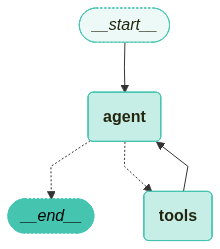

In [4]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app)

### 에이전트 테스트

기본 에이전트가 대화를 기억하는지 테스트합니다. 첫 번째 메시지에서 이름을 알려주고, 두 번째 메시지에서 이름을 물어보면 체크포인터에 저장된 대화 기록을 바탕으로 답변합니다.

아래 코드에서는 연속으로 두 번 대화를 수행합니다.

In [5]:
from langchain_core.messages import HumanMessage

# 스레드 ID가 1인 설정 객체 초기화
config = {"configurable": {"thread_id": "1"}}

# 첫 번째 질문
input_message = HumanMessage(content="안녕하세요! 제 이름은 Teddy입니다.")

# 스트림 모드로 메시지 처리 및 응답 출력
for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

안녕하세요! 제 이름은 Teddy입니다.
================================== Ai Message ==================================

안녕하세요, Teddy! 만나서 반가워요. 어떻게 도와드릴까요?


In [6]:
# 후속 질문: 이름 기억 확인
input_message = HumanMessage(content="제 이름이 뭐라고 했죠?")

for event in app.stream({"messages": [input_message]}, config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

제 이름이 뭐라고 했죠?
================================== Ai Message ==================================

당신의 이름은 Teddy입니다. 맞나요?


In [7]:
# 현재 저장된 메시지 확인
messages = app.get_state(config).values["messages"]
print(f"현재 저장된 메시지 수: {len(messages)}개\n")

for message in messages:
    message.pretty_print()

현재 저장된 메시지 수: 4개

================================ Human Message =================================

안녕하세요! 제 이름은 Teddy입니다.
================================== Ai Message ==================================

안녕하세요, Teddy! 만나서 반가워요. 어떻게 도와드릴까요?
================================ Human Message =================================

제 이름이 뭐라고 했죠?
================================== Ai Message ==================================

당신의 이름은 Teddy입니다. 맞나요?


---

## 메시지 트리밍(Trimming)

대부분의 LLM에는 최대 지원 컨텍스트 윈도우(토큰 단위)가 있습니다. 대화가 길어지면 이 한계에 도달하여 오류가 발생하거나 컨텍스트가 손실될 수 있습니다. `trim_messages` 함수를 사용하면 메시지 기록의 토큰 수를 계산하고, 한계에 도달했을 때 오래된 메시지를 트리밍할 수 있습니다.

### trim_messages 함수

`langchain_core.messages`의 `trim_messages` 함수는 다음과 같은 옵션을 제공합니다:

- `strategy`: "last"(최근 메시지 유지) 또는 "first"(첫 메시지 유지)
- `max_tokens`: 유지할 최대 토큰 수
- `token_counter`: 토큰 수를 계산하는 함수 또는 LLM 모델
- `start_on`: 시작할 메시지 타입 ("human", "ai" 등)
- `include_system`: 시스템 메시지 포함 여부 (strategy가 "last"일 경우에만 사용)

### token_counter 주의사항

`token_counter` 파라미터에는 **LLM 모델 객체**를 전달하는 것이 권장됩니다. `token_counter=len`처럼 `len` 함수를 전달하면 메시지 **개수**를 토큰 수로 잘못 계산하여 트리밍이 제대로 작동하지 않습니다.

```python
# 잘못된 사용 (메시지 개수를 토큰으로 계산)
trim_messages(messages, max_tokens=100, token_counter=len)

# 올바른 사용 (LLM 모델로 정확한 토큰 계산)
trim_messages(messages, max_tokens=100, token_counter=model)
```

아래 코드에서는 LLM 모델을 token_counter로 사용하여 트리밍 전략을 테스트합니다.

In [8]:
from langchain_core.messages import trim_messages, HumanMessage, AIMessage, SystemMessage

# 긴 대화 히스토리 시뮬레이션
sample_messages = [
    SystemMessage(content="당신은 친절한 어시스턴트입니다."),
    HumanMessage(content="안녕하세요"),
    AIMessage(content="안녕하세요! 무엇을 도와드릴까요?"),
    HumanMessage(content="날씨가 어때요?"),
    AIMessage(content="오늘은 맑은 날씨입니다."),
    HumanMessage(content="추천 음식이 있나요?"),
    AIMessage(content="파스타를 추천합니다."),
    HumanMessage(content="레시피를 알려주세요"),
    AIMessage(content="토마토 파스타 레시피입니다. 먼저 토마토를 준비하고..."),
    HumanMessage(content="감사합니다"),
    AIMessage(content="천만에요! 다른 질문이 있으시면 말씀해주세요."),
]

print(f"원본 메시지 수: {len(sample_messages)}개")

원본 메시지 수: 11개


In [9]:
# 전략 1: 최근 메시지만 유지 (strategy="last")
# token_counter에 LLM 모델을 전달하면 정확한 토큰 수를 계산합니다.
trimmed_last = trim_messages(
    sample_messages,
    strategy="last",
    max_tokens=100,  # 최대 100 토큰만 유지
    token_counter=model,  # LLM 모델을 전달하여 정확한 토큰 계산
    start_on="human",  # 사람 메시지로 시작
    include_system=True,  # 시스템 메시지 포함
)

print("전략 1 - 최근 메시지 유지 (strategy='last'):")
print(f"트리밍 후 메시지 수: {len(trimmed_last)}개\n")
for msg in trimmed_last:
    print(f"  [{msg.type}] {msg.content[:50]}..." if len(msg.content) > 50 else f"  [{msg.type}] {msg.content}")

전략 1 - 최근 메시지 유지 (strategy='last'):
트리밍 후 메시지 수: 7개

  [system] 당신은 친절한 어시스턴트입니다.
  [human] 추천 음식이 있나요?
  [ai] 파스타를 추천합니다.
  [human] 레시피를 알려주세요
  [ai] 토마토 파스타 레시피입니다. 먼저 토마토를 준비하고...
  [human] 감사합니다
  [ai] 천만에요! 다른 질문이 있으시면 말씀해주세요.


In [10]:
# 전략 2: 첫 메시지 유지 (strategy="first")
trimmed_first = trim_messages(
    sample_messages,
    strategy="first",
    max_tokens=100,
    token_counter=model,  # LLM 모델을 전달하여 정확한 토큰 계산
)

print("전략 2 - 첫 메시지 유지 (strategy='first'):")
print(f"트리밍 후 메시지 수: {len(trimmed_first)}개\n")
for msg in trimmed_first:
    print(f"  [{msg.type}] {msg.content[:50]}..." if len(msg.content) > 50 else f"  [{msg.type}] {msg.content}")

전략 2 - 첫 메시지 유지 (strategy='first'):
트리밍 후 메시지 수: 8개

  [system] 당신은 친절한 어시스턴트입니다.
  [human] 안녕하세요
  [ai] 안녕하세요! 무엇을 도와드릴까요?
  [human] 날씨가 어때요?
  [ai] 오늘은 맑은 날씨입니다.
  [human] 추천 음식이 있나요?
  [ai] 파스타를 추천합니다.
  [human] 레시피를 알려주세요


### 그래프에서 트리밍 적용

LLM을 호출하기 전에 메시지를 트리밍하여 컨텍스트 윈도우 제한을 관리할 수 있습니다. 아래 예제에서는 에이전트 노드에서 LLM을 호출하기 전에 자동으로 메시지를 트리밍합니다.

아래 코드에서는 트리밍이 적용된 에이전트를 구축합니다.

In [11]:
# 새로운 체크포인터 생성
memory_trimmed = MemorySaver()


def call_model_with_trimming(state: MessagesState):
    """트리밍이 적용된 에이전트 노드
    
    LLM 호출 전에 메시지를 트리밍하여 컨텍스트 관리를 수행합니다.
    """
    # 메시지 트리밍 - 최대 500 토큰만 유지
    # token_counter에 LLM 모델을 전달하여 정확한 토큰 계산
    trimmed_messages = trim_messages(
        state["messages"],
        strategy="last",
        max_tokens=500,
        token_counter=model,  # LLM 모델 전달
        start_on="human",
        include_system=True,
    )
    
    # 트리밍된 메시지로 LLM 호출
    response = model_with_tools.invoke(trimmed_messages)
    return {"messages": [response]}


# 트리밍이 적용된 워크플로우 생성
workflow_trimmed = StateGraph(MessagesState)
workflow_trimmed.add_node("agent", call_model_with_trimming)
workflow_trimmed.add_node("tools", tool_node)
workflow_trimmed.add_edge(START, "agent")
workflow_trimmed.add_conditional_edges("agent", tools_condition)
workflow_trimmed.add_edge("tools", "agent")

app_trimmed = workflow_trimmed.compile(checkpointer=memory_trimmed)

print("트리밍이 적용된 에이전트 생성 완료!")

트리밍이 적용된 에이전트 생성 완료!


---

## RemoveMessage를 사용한 메시지 삭제

`RemoveMessage`는 LangGraph에서 제공하는 특수 수정자로, 메시지 목록에서 특정 메시지를 영구적으로 삭제할 때 사용합니다. 트리밍과 달리 메시지가 실제로 상태에서 제거되므로, 저장된 데이터 양을 줄이거나 민감한 정보를 삭제하는 데 유용합니다.

### 수동으로 메시지 삭제

`update_state()` 메서드와 `RemoveMessage`를 함께 사용하면 그래프 상태에서 원하는 메시지를 선택적으로 제거할 수 있습니다. 각 메시지는 고유한 `id` 속성을 가지고 있어 정확하게 삭제 대상을 지정할 수 있습니다.

아래 코드에서는 저장된 메시지 중 첫 번째 메시지를 삭제합니다.

In [12]:
from langchain_core.messages import RemoveMessage

# 현재 저장된 메시지 확인
messages = app.get_state(config).values["messages"]
print(f"삭제 전 메시지 수: {len(messages)}개\n")

for i, msg in enumerate(messages):
    print(f"  [{i}] {msg.type}: {msg.content[:40]}..." if len(msg.content) > 40 else f"  [{i}] {msg.type}: {msg.content}")

삭제 전 메시지 수: 4개

  [0] human: 안녕하세요! 제 이름은 Teddy입니다.
  [1] ai: 안녕하세요, Teddy! 만나서 반가워요. 어떻게 도와드릴까요?
  [2] human: 제 이름이 뭐라고 했죠?
  [3] ai: 당신의 이름은 Teddy입니다. 맞나요?


In [13]:
# 첫 번째 메시지 삭제
app.update_state(config, {"messages": RemoveMessage(id=messages[0].id)})

# 삭제 결과 확인
messages_after = app.get_state(config).values["messages"]
print(f"삭제 후 메시지 수: {len(messages_after)}개\n")

for i, msg in enumerate(messages_after):
    print(f"  [{i}] {msg.type}: {msg.content[:40]}..." if len(msg.content) > 40 else f"  [{i}] {msg.type}: {msg.content}")

삭제 후 메시지 수: 3개

  [0] ai: 안녕하세요, Teddy! 만나서 반가워요. 어떻게 도와드릴까요?
  [1] human: 제 이름이 뭐라고 했죠?
  [2] ai: 당신의 이름은 Teddy입니다. 맞나요?


---

## 그래프 내부에서 동적으로 메시지 삭제

수동 삭제 외에도 그래프 실행 중에 자동으로 오래된 메시지를 삭제하는 로직을 구현할 수 있습니다. 이는 대화가 길어질 때 컨텍스트 윈도우를 관리하거나 토큰 비용을 절약하는 데 유용합니다.

아래 예시에서는 그래프 실행이 종료될 때 최근 3개 메시지만 유지하고 나머지는 자동으로 삭제하는 `delete_messages` 노드를 추가합니다.

In [14]:
from typing import Literal
from langchain_core.messages import RemoveMessage

# 새로운 체크포인터 생성
memory_auto_delete = MemorySaver()


def delete_messages(state: MessagesState):
    """오래된 메시지 삭제 노드
    
    메시지가 3개를 초과하면 최신 3개만 유지하고 나머지를 삭제합니다.
    """
    messages = state["messages"]
    if len(messages) > 3:
        # 오래된 메시지 삭제 (최신 3개만 유지)
        return {"messages": [RemoveMessage(id=m.id) for m in messages[:-3]]}
    return {}


def should_continue(state: MessagesState) -> Literal["tools", "delete_messages"]:
    """조건부 라우팅 함수
    
    도구 호출이 있으면 tools 노드로, 없으면 delete_messages 노드로 이동합니다.
    """
    last_message = state["messages"][-1]
    # 도구 호출이 없으면 메시지 삭제 노드로 이동
    if not last_message.tool_calls:
        return "delete_messages"
    return "tools"


# 동적 삭제가 포함된 워크플로우 생성
workflow_auto = StateGraph(MessagesState)

# 노드 추가
workflow_auto.add_node("agent", call_model)
workflow_auto.add_node("tools", tool_node)
workflow_auto.add_node("delete_messages", delete_messages)

# 엣지 추가
workflow_auto.add_edge(START, "agent")
workflow_auto.add_conditional_edges("agent", should_continue)
workflow_auto.add_edge("tools", "agent")
workflow_auto.add_edge("delete_messages", END)

# 컴파일
app_auto = workflow_auto.compile(checkpointer=memory_auto_delete)

print("동적 삭제가 적용된 에이전트 생성 완료!")

동적 삭제가 적용된 에이전트 생성 완료!


### 수정된 그래프 시각화

수정된 그래프에는 `delete_messages` 노드가 추가되었습니다. 에이전트가 도구 호출 없이 응답을 완료하면 `delete_messages` 노드를 거쳐 종료됩니다.

아래 코드는 수정된 그래프를 시각화합니다.

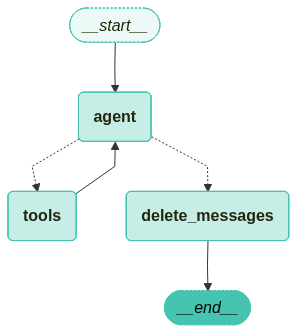

In [15]:
# 그래프 시각화
visualize_graph(app_auto)

### 동적 삭제 테스트

이제 그래프를 여러 번 호출하여 메시지가 누적되는지, 그리고 오래된 메시지가 자동으로 삭제되는지 확인해보겠습니다. 각 호출 후 상태에는 최신 3개의 메시지만 유지됩니다.

아래 코드에서는 연속으로 여러 번 대화를 수행합니다.

In [16]:
# 새로운 스레드 ID로 설정
config_auto = {"configurable": {"thread_id": "auto_delete_test"}}

# 첫 번째 대화
input1 = HumanMessage(content="안녕하세요! 저는 철수입니다.")
for event in app_auto.stream({"messages": [input1]}, config_auto, stream_mode="values"):
    event["messages"][-1].pretty_print()

print(f"\n현재 메시지 수: {len(app_auto.get_state(config_auto).values['messages'])}개")

================================ Human Message =================================

안녕하세요! 저는 철수입니다.
================================== Ai Message ==================================

안녕하세요, 철수님! 어떻게 도와드릴까요?

현재 메시지 수: 2개


In [17]:
# 두 번째 대화
input2 = HumanMessage(content="제 이름이 뭐라고 했죠?")
for event in app_auto.stream({"messages": [input2]}, config_auto, stream_mode="values"):
    event["messages"][-1].pretty_print()

print(f"\n현재 메시지 수: {len(app_auto.get_state(config_auto).values['messages'])}개")

================================ Human Message =================================

제 이름이 뭐라고 했죠?
================================== Ai Message ==================================

당신의 이름은 철수입니다.
================================== Ai Message ==================================

당신의 이름은 철수입니다.

현재 메시지 수: 3개


In [18]:
# 세 번째 대화 (이 시점에서 오래된 메시지 삭제 예상)
input3 = HumanMessage(content="오늘 날씨는 어때요?")
for event in app_auto.stream({"messages": [input3]}, config_auto, stream_mode="values"):
    event["messages"][-1].pretty_print()

print(f"\n현재 메시지 수: {len(app_auto.get_state(config_auto).values['messages'])}개")

================================ Human Message =================================

오늘 날씨는 어때요?
================================== Ai Message ==================================
Tool Calls:
  search (call_vdi67oi2oSSLOoQUQ946BHPW)
 Call ID: call_vdi67oi2oSSLOoQUQ946BHPW
  Args:
    query: 오늘 서울 날씨
================================= Tool Message =================================
Name: search

검색 결과: '오늘 서울 날씨'에 대한 정보를 찾았습니다. LangGraph는 상태 기반 워크플로우를 구축하는 프레임워크입니다.
================================== Ai Message ==================================

오늘 서울의 날씨에 대한 정보를 찾을 수 없었습니다. 다른 방법으로 확인해 보시거나 다른 질문이 있으시면 말씀해 주세요!
================================== Ai Message ==================================

오늘 서울의 날씨에 대한 정보를 찾을 수 없었습니다. 다른 방법으로 확인해 보시거나 다른 질문이 있으시면 말씀해 주세요!

현재 메시지 수: 3개


In [19]:
# 최종 상태 확인
final_messages = app_auto.get_state(config_auto).values["messages"]
print(f"최종 메시지 수: {len(final_messages)}개\n")

for msg in final_messages:
    msg.pretty_print()

최종 메시지 수: 3개

================================== Ai Message ==================================
Tool Calls:
  search (call_vdi67oi2oSSLOoQUQ946BHPW)
 Call ID: call_vdi67oi2oSSLOoQUQ946BHPW
  Args:
    query: 오늘 서울 날씨
================================= Tool Message =================================
Name: search

검색 결과: '오늘 서울 날씨'에 대한 정보를 찾았습니다. LangGraph는 상태 기반 워크플로우를 구축하는 프레임워크입니다.
================================== Ai Message ==================================

오늘 서울의 날씨에 대한 정보를 찾을 수 없었습니다. 다른 방법으로 확인해 보시거나 다른 질문이 있으시면 말씀해 주세요!


---

## 대화 요약을 통한 컨텍스트 압축

메시지를 트리밍하거나 삭제하면 정보가 손실될 수 있습니다. 대화 요약(summarization)은 오래된 메시지들의 핵심 내용을 압축하여 컨텍스트를 유지하면서도 토큰 사용량을 줄이는 방법입니다.

### 요약 전략

1. 오래된 메시지들을 LLM을 사용하여 요약
2. 요약 내용을 시스템 메시지로 추가
3. 원본 메시지는 삭제

아래 코드에서는 대화 요약 기능을 구현합니다.

In [20]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


# 요약을 저장할 수 있는 확장된 State
class SummaryState(TypedDict):
    """요약 기능이 포함된 State
    
    messages: 대화 메시지 리스트
    summary: 이전 대화의 요약 (선택적)
    """
    messages: Annotated[list, add_messages]
    summary: str


def summarize_conversation(messages: list) -> str:
    """대화 내용을 요약하는 함수
    
    주어진 메시지 리스트를 LLM을 사용하여 2-3문장으로 요약합니다.
    """
    # 요약을 위한 프롬프트
    summary_prompt = f"""
    다음 대화 내용을 2-3문장으로 요약해주세요.
    핵심 정보와 컨텍스트를 유지하면서 간결하게 작성해주세요.
    
    대화 내용:
    {chr(10).join([f"{msg.type}: {msg.content}" for msg in messages])}
    """
    
    # LLM으로 요약 생성
    summary_response = model.invoke([HumanMessage(content=summary_prompt)])
    return summary_response.content


print("대화 요약 함수 정의 완료!")

대화 요약 함수 정의 완료!


In [21]:
# 요약 테스트
test_summary = summarize_conversation(sample_messages[1:])  # 시스템 메시지 제외
print("대화 요약 결과:")
print(test_summary)

대화 요약 결과:
사람이 AI와의 대화에서 날씨와 음식 추천을 물어보았고, AI는 오늘의 날씨가 맑음을 알리고 파스타를 추천했습니다. 그 후, AI는 토마토 파스타 레시피를 제공하며 대화가 끝났습니다.


### 요약이 포함된 에이전트 구축

이제 대화가 길어지면 자동으로 요약을 생성하고, 요약된 내용을 컨텍스트로 사용하는 에이전트를 구축합니다. 이 방식은 정보 손실을 최소화하면서 토큰 효율성을 높입니다.

아래 코드에서는 요약 기능이 포함된 에이전트를 구축합니다.

In [22]:
# 새로운 체크포인터 생성
memory_summary = MemorySaver()


def call_model_with_summary(state: SummaryState):
    """요약을 활용하는 에이전트 노드
    
    이전 대화 요약이 있으면 시스템 메시지로 추가하여 컨텍스트를 유지합니다.
    """
    # 요약이 있으면 시스템 메시지로 추가
    messages = state["messages"]
    if state.get("summary"):
        system_msg = SystemMessage(content=f"이전 대화 요약: {state['summary']}")
        messages = [system_msg] + list(messages)
    
    response = model_with_tools.invoke(messages)
    return {"messages": [response]}


def maybe_summarize(state: SummaryState):
    """조건부 요약 노드
    
    메시지가 6개를 초과하면 처음 4개를 요약하고 삭제합니다.
    """
    messages = state["messages"]
    
    if len(messages) > 6:
        # 처음 4개 메시지 요약
        messages_to_summarize = messages[:4]
        summary = summarize_conversation(messages_to_summarize)
        
        # 요약된 메시지 삭제
        delete_messages = [RemoveMessage(id=m.id) for m in messages_to_summarize]
        
        return {
            "messages": delete_messages,
            "summary": summary
        }
    
    return {}


def should_continue_summary(state: SummaryState) -> Literal["tools", "summarize"]:
    """조건부 라우팅 함수"""
    last_message = state["messages"][-1]
    if not last_message.tool_calls:
        return "summarize"
    return "tools"


# 요약 기능이 포함된 워크플로우 생성
workflow_summary = StateGraph(SummaryState)

workflow_summary.add_node("agent", call_model_with_summary)
workflow_summary.add_node("tools", tool_node)
workflow_summary.add_node("summarize", maybe_summarize)

workflow_summary.add_edge(START, "agent")
workflow_summary.add_conditional_edges("agent", should_continue_summary)
workflow_summary.add_edge("tools", "agent")
workflow_summary.add_edge("summarize", END)

app_summary = workflow_summary.compile(checkpointer=memory_summary)

print("요약 기능이 포함된 에이전트 생성 완료!")

요약 기능이 포함된 에이전트 생성 완료!


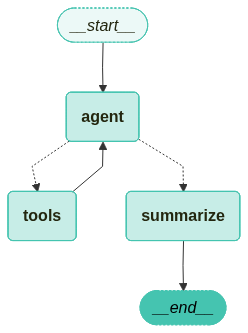

In [23]:
# 그래프 시각화
visualize_graph(app_summary)

---

## 정리

이번 튜토리얼에서는 LangGraph의 단기 메모리를 효과적으로 관리하는 방법을 학습했습니다.

### 핵심 내용

| 기법 | 특징 | 사용 사례 |
|------|------|----------|
| 트리밍 | LLM 호출 전 메시지 필터링 | 컨텍스트 윈도우 제한 관리 |
| 삭제 | 상태에서 메시지 영구 제거 | 민감 정보 삭제, 저장 공간 관리 |
| 요약 | 오래된 메시지를 압축 | 정보 손실 최소화하면서 토큰 절약 |

### 전략 선택 가이드

- **트리밍**: 간단하고 빠름, 정보 손실 가능
- **삭제**: 저장 공간 절약, 정보 손실 가능
- **요약**: 정보 보존, 추가 LLM 호출 비용 발생